# Preprocessing Analysis

**Three array types (all node/chunk files concatenated per fold):**
- `mces_indexes` — 3 cols `[mol_i, mol_j, MCES]` — **all** pairs (trivial sentinels + computed)
- `edit_distance_indexes` — 3 cols `[mol_i, mol_j, ED]` — **all** pairs (same pairs, different distance)
- `ed_mces_indexes` — 4 cols `[mol_i, mol_j, ED, MCES]` — only pairs where **both** distances are non-NaN

**Sentinels in trivial pairs:**
- `dist == 0` with `i == j` → self-pair
- `dist == 666` → Tanimoto < 0.2 (molecules too dissimilar, skipped entirely)
- `dist == NaN` → >40 heavy atoms (too large for MCES ILP)

**MCES values in computed pairs:**
- `MCES < 20` — reliable LP-relaxation lower bound (close to true integer MCES)
- `MCES == 20` exactly — **solver threshold hit**: the ILP lower bound reached 20 before finding an exact solution; true MCES ≥ 20 but exact value unknown. This causes the large spike at 20 in val/test (which have proportionally more dissimilar pairs than train).
- `MCES > 20` — LP lower bound exceeded threshold (true MCES definitely > 20)
- `MCES == NaN` — computation timed out or failed

In [16]:
import pickle
import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches

PREPRO_DIR = Path("/mnt/data2/nkubrakov/massspecgym/preprocessing_th20_asb")
FOLDS = ["train", "val", "test"]
FOLD_COLORS = {"train": "#4C72B0", "val": "#DD8452", "test": "#55A868"}
MCES_THRESHOLD = 20.0   # myopic_mces --threshold value

## 1. Load data

In [17]:
with open(PREPRO_DIR / "mapping.pkl", "rb") as f:
    mapping = pickle.load(f)

dfs = {fold: mapping[f"df_smiles_{fold}"] for fold in FOLDS}
spectrum_indexes = {fold: mapping[f"spectrum_indexes_{fold}"] for fold in FOLDS}

print("Format version:", mapping.get("format_version", "unknown"))
for fold in FOLDS:
    n = len(dfs[fold])
    theo = n * (n - 1) // 2
    print(f"  {fold:6s}: {n:6,} unique molecules  "
          f"{len(spectrum_indexes[fold]):7,} spectra  "
          f"theoretical unique undirected pairs: {theo:,}")

Format version: lightweight
  train : 22,577 unique molecules  122,422 spectra  theoretical unique undirected pairs: 254,849,176
  val   :  3,042 unique molecules   10,791 spectra  theoretical unique undirected pairs: 4,625,361
  test  :  2,888 unique molecules   10,747 spectra  theoretical unique undirected pairs: 4,168,828


In [ ]:

# Show all metadata keys in mapping (everything that isn't a dataframe or array)
import pprint

meta = {k: v for k, v in mapping.items()
        if not hasattr(v, '__len__') or isinstance(v, (str, int, float, bool, dict, list))}
print("=== Mapping metadata ===")
pprint.pprint(meta)

# Also show the preprocessing SLURM script for full param record
slurm_scripts = sorted(Path("/home/nkubrakov/simba/tools/slurm").glob("*preprocessing*th20_asb*.slurm.sh"))
for p in slurm_scripts:
    print(f"\n=== {p.name} ===")
    print(p.read_text())


In [18]:
def load_fold(fold, prefix):
    """Concatenate all node/chunk npy files for a given fold and array prefix."""
    files = sorted(glob.glob(str(PREPRO_DIR / f"{prefix}_tani_incremental_{fold}_*.npy")))
    return np.concatenate([np.load(f, allow_pickle=False) for f in files], axis=0)

# Three array types:
#   mces_arr  — all pairs, col2 = MCES
#   ed_arr    — all pairs, col2 = ED
#   edm_arr   — pairs where BOTH distances are non-NaN, col2=ED col3=MCES
mces_arr = {fold: load_fold(fold, "mces_indexes")          for fold in FOLDS}
ed_arr   = {fold: load_fold(fold, "edit_distance_indexes") for fold in FOLDS}
edm_arr  = {fold: load_fold(fold, "ed_mces_indexes")       for fold in FOLDS}

for fold in FOLDS:
    n = len(dfs[fold])
    theo = n * (n - 1) // 2
    print(f"{fold}: mces={len(mces_arr[fold]):,}  ed={len(ed_arr[fold]):,}  "
          f"ed_mces={len(edm_arr[fold]):,}  (theo undirected: {theo:,})")

train: mces=509,720,929  ed=509,720,929  ed_mces=192,362,180  (theo undirected: 254,849,176)
val: mces=9,253,764  ed=9,253,764  ed_mces=2,279,684  (theo undirected: 4,625,361)
test: mces=8,340,544  ed=8,340,544  ed_mces=2,152,237  (theo undirected: 4,168,828)


In [19]:
def classify(arr):
    """
    Classify rows of mces_indexes (3-col: mol_i, mol_j, MCES) into categories.
    Returns a dict of boolean masks.
    """
    i, j, dist = arr[:, 0].astype(int), arr[:, 1].astype(int), arr[:, 2]

    self_pair  = (i == j) & (dist == 0)
    tani_low   = dist == 666.0
    large_mol  = ~self_pair & ~tani_low & np.isnan(dist)
    computed   = ~self_pair & ~tani_low & ~large_mol

    # MCES sub-categories within computed pairs
    mces_exact  = computed & (dist < MCES_THRESHOLD)                     # reliable LP value
    mces_capped = computed & (dist == MCES_THRESHOLD)                    # threshold hit; true >= 20
    mces_lb     = computed & (dist > MCES_THRESHOLD) & ~np.isnan(dist)  # LP lower bound > threshold
    mces_nan    = computed & np.isnan(dist)                              # timeout / failed

    return dict(
        self=self_pair, tani_low=tani_low, large_mol=large_mol, computed=computed,
        mces_exact=mces_exact, mces_capped=mces_capped, mces_lb=mces_lb, mces_nan=mces_nan,
    )

cls = {fold: classify(mces_arr[fold]) for fold in FOLDS}

## 2. Per-fold summary

In [20]:
rows = []
for fold in FOLDS:
    n     = len(dfs[fold])
    theo  = n * (n - 1) // 2
    c     = cls[fold]
    total = len(mces_arr[fold])
    comp  = c["computed"].sum()
    rows.append({
        "Fold":                   fold,
        "Unique molecules":       f"{n:,}",
        "Spectra":                f"{len(spectrum_indexes[fold]):,}",
        "Theoretical pairs":      f"{theo:,}",
        "Stored rows (directed)": f"{total:,}",
        "Self-pairs":             f"{c['self'].sum():,}",
        "Tanimoto<0.2":           f"{c['tani_low'].sum():,} ({c['tani_low'].mean()*100:.1f}%)",
        ">40 atoms":              f"{c['large_mol'].sum():,} ({c['large_mol'].mean()*100:.1f}%)",
        "Computed":               f"{comp:,} ({comp/total*100:.1f}%)",
        "  MCES<20 (exact)":      f"{c['mces_exact'].sum():,} ({c['mces_exact'].sum()/max(comp,1)*100:.1f}%)",
        "  MCES=20 (capped)": f"{c['mces_capped'].sum():,} ({c['mces_capped'].sum()/max(comp,1)*100:.1f}%)",
        "  MCES>20 (lb>θ)": f"{c['mces_lb'].sum():,} ({c['mces_lb'].sum()/max(comp,1)*100:.1f}%)",
        "  MCES NaN (fail)":      f"{c['mces_nan'].sum():,} ({c['mces_nan'].sum()/max(comp,1)*100:.3f}%)",
        "Both ED+MCES valid":     f"{len(edm_arr[fold]):,}",
    })

pd.DataFrame(rows).set_index("Fold").T

Fold,train,val,test
Unique molecules,"22,577","3,042","2,888"
Spectra,"122,422","10,791","10,747"
Theoretical pairs,"254,849,176","4,625,361","4,168,828"
Stored rows (directed),"509,720,929","9,253,764","8,340,544"
Self-pairs,"22,577","3,042","2,888"
Tanimoto<0.2,"186,309,664 (36.6%)","2,035,326 (22.0%)","1,604,942 (19.2%)"
>40 atoms,"54,606,127 (10.7%)","2,335,833 (25.2%)","2,265,170 (27.2%)"
Computed,"268,782,561 (52.7%)","4,879,563 (52.7%)","4,467,544 (53.6%)"
MCES<20 (exact),"39,423,944 (14.7%)","55,990 (1.1%)","50,075 (1.1%)"
MCES=20 (capped),"68,750,954 (25.6%)","984,554 (20.2%)","915,096 (20.5%)"


## 3. Pair category breakdown (stacked bar)

MCES "computed" is split into sub-categories to show how many pairs have exact MCES < 20 vs. capped at threshold vs. lower bound > threshold.

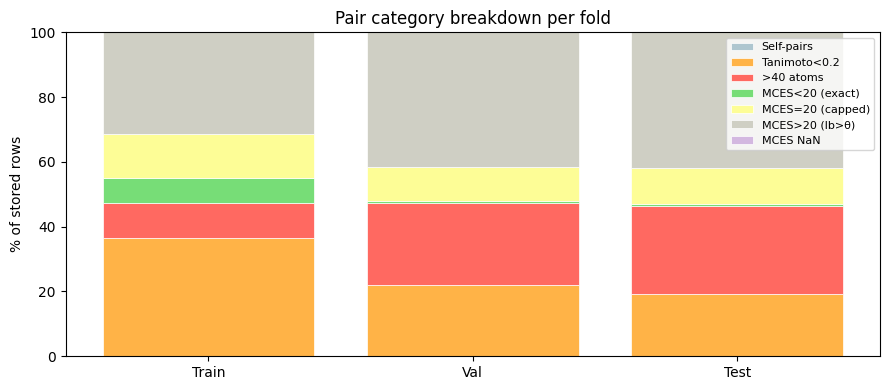

In [21]:
cat_labels = ["Self-pairs", "Tanimoto<0.2", ">40 atoms",
              "MCES<20 (exact)", "MCES=20 (capped)", "MCES>20 (lb>θ)", "MCES NaN"]
cat_keys   = ["self", "tani_low", "large_mol",
              "mces_exact", "mces_capped", "mces_lb", "mces_nan"]
cat_colors = ["#aec6cf", "#ffb347", "#ff6961",
              "#77dd77", "#fdfd96", "#cfcfc4", "#d3b8e0"]

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(FOLDS))
bottoms = np.zeros(len(FOLDS))

for key, label, color in zip(cat_keys, cat_labels, cat_colors):
    counts = np.array([cls[f][key].sum() for f in FOLDS], dtype=float)
    totals = np.array([len(mces_arr[f]) for f in FOLDS], dtype=float)
    fracs  = counts / totals * 100
    ax.bar(x, fracs, bottom=bottoms, label=label, color=color, edgecolor="white", linewidth=0.5)
    bottoms += fracs

ax.set_xticks(x)
ax.set_xticklabels([f.capitalize() for f in FOLDS])
ax.set_ylabel("% of stored rows")
ax.set_ylim(0, 100)
ax.set_title("Pair category breakdown per fold")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Spectra per molecule distribution

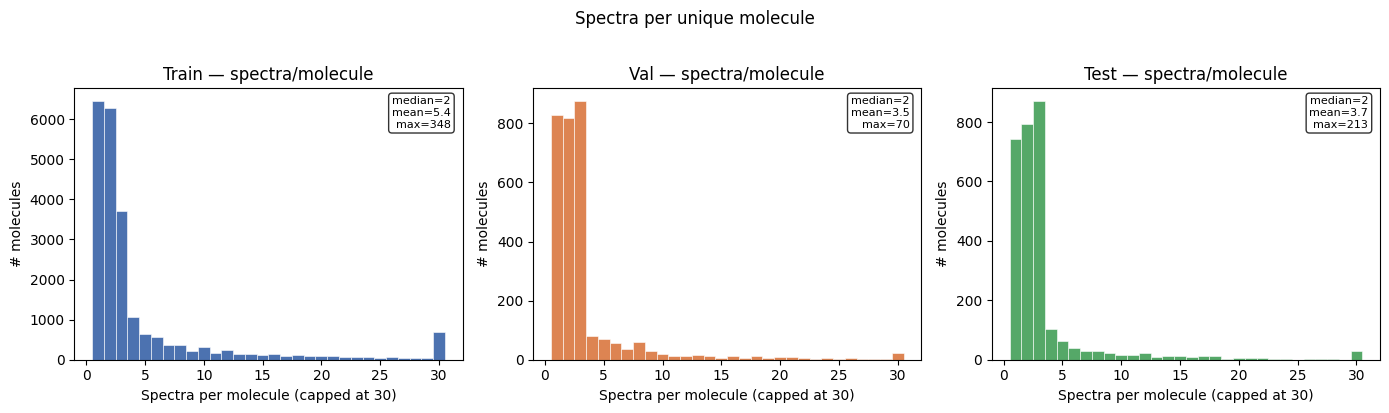

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, fold in zip(axes, FOLDS):
    counts = dfs[fold]["number_indexes"]
    max_val = min(counts.max(), 30)
    bins = np.arange(0.5, max_val + 1.5)
    ax.hist(counts.clip(upper=max_val), bins=bins, color=FOLD_COLORS[fold], edgecolor="white", linewidth=0.4)
    ax.set_title(f"{fold.capitalize()} — spectra/molecule")
    ax.set_xlabel("Spectra per molecule" + (f" (capped at {max_val})" if counts.max() > max_val else ""))
    ax.set_ylabel("# molecules")
    ax.text(0.97, 0.97, f"median={counts.median():.0f}\nmean={counts.mean():.1f}\nmax={counts.max()}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.suptitle("Spectra per unique molecule", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 5. Pairs per molecule (degree distribution)

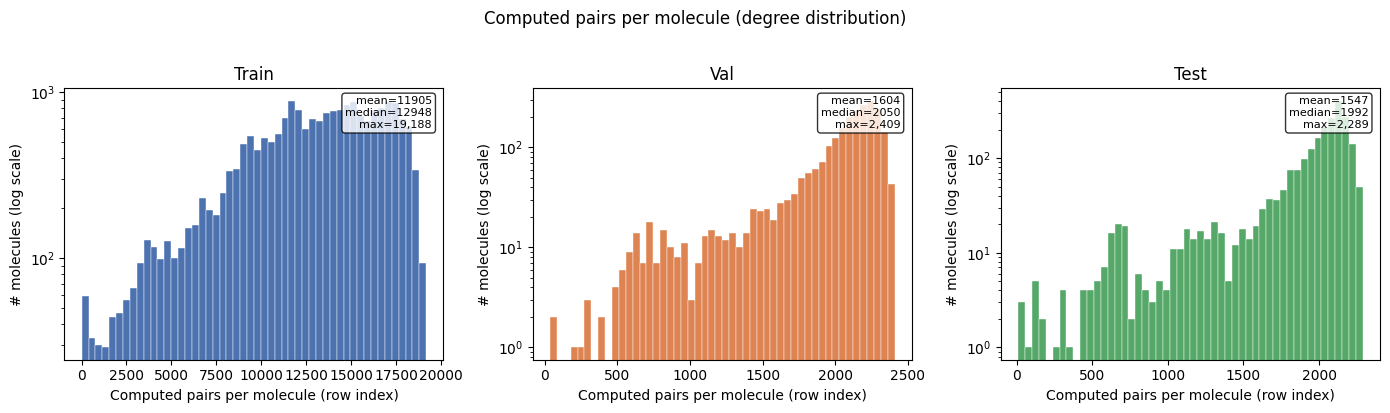

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, fold in zip(axes, FOLDS):
    arr  = mces_arr[fold]
    c    = cls[fold]
    computed_mask = c["computed"]
    i_idx = arr[computed_mask, 0].astype(int)

    n_mols = len(dfs[fold])
    degree = np.bincount(i_idx, minlength=n_mols)

    ax.hist(degree[degree > 0], bins=50, color=FOLD_COLORS[fold], edgecolor="white", linewidth=0.3, log=True)
    ax.set_title(f"{fold.capitalize()}")
    ax.set_xlabel("Computed pairs per molecule (row index)")
    ax.set_ylabel("# molecules (log scale)")
    ax.text(0.97, 0.97, f"mean={degree.mean():.0f}\nmedian={np.median(degree):.0f}\nmax={degree.max():,}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.suptitle("Computed pairs per molecule (degree distribution)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 6. MCES distance distribution

**Why the spike at MCES=20?** The `myopic_mces` solver uses `--threshold 20`. When the ILP lower bound reaches 20 before finding an exact solution, it stops and reports 20. So `MCES == 20` means *true MCES ≥ 20, exact value unknown*. Val and test have a much larger spike than train because their molecules are more structurally diverse (by dataset split design), so a greater fraction of pairs are truly dissimilar.

- **Top row:** full distribution (note the cap spike at 20)  
- **Bottom row:** exact values only (`MCES < 20`) — the reliable region

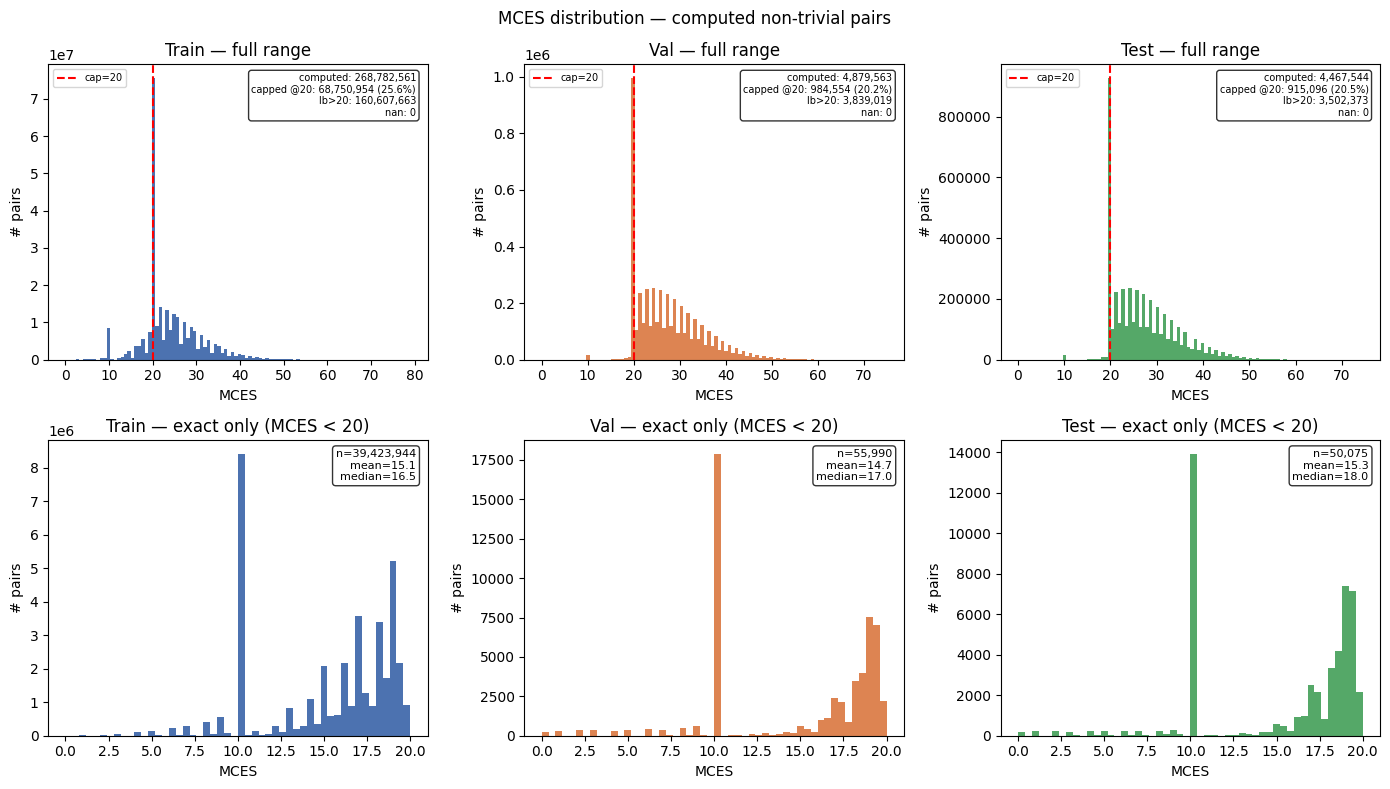

In [24]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

for col, fold in enumerate(FOLDS):
    dist  = mces_arr[fold][:, 2]
    c     = cls[fold]
    comp  = c["computed"]
    valid = dist[comp & ~np.isnan(dist)]   # all computed, non-NaN
    exact = dist[c["mces_exact"]]          # MCES < 20 only
    n_cap = c["mces_capped"].sum()
    n_lb  = c["mces_lb"].sum()
    n_nan = c["mces_nan"].sum()

    # Top: full range
    ax = axes[0, col]
    ax.hist(valid, bins=100, color=FOLD_COLORS[fold], edgecolor="none")
    ax.axvline(MCES_THRESHOLD, color="red", lw=1.5, ls="--", label=f"cap={MCES_THRESHOLD:.0f}")
    ax.set_title(f"{fold.capitalize()} — full range")
    ax.set_xlabel("MCES")
    ax.set_ylabel("# pairs")
    ax.legend(fontsize=7)
    ax.text(0.97, 0.97,
            f"computed: {comp.sum():,}\ncapped @20: {n_cap:,} ({n_cap/max(comp.sum(),1)*100:.1f}%)\n"
            f"lb>20: {n_lb:,}\nnan: {n_nan:,}",
            transform=ax.transAxes, ha="right", va="top", fontsize=7,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

    # Bottom: exact only (MCES < threshold)
    ax = axes[1, col]
    ax.hist(exact, bins=50, color=FOLD_COLORS[fold], edgecolor="none")
    ax.set_title(f"{fold.capitalize()} — exact only (MCES < 20)")
    ax.set_xlabel("MCES")
    ax.set_ylabel("# pairs")
    if len(exact):
        ax.text(0.97, 0.97,
                f"n={len(exact):,}\nmean={exact.mean():.1f}\nmedian={np.median(exact):.1f}",
                transform=ax.transAxes, ha="right", va="top", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.suptitle("MCES distribution — computed non-trivial pairs", fontsize=12)
plt.tight_layout()
plt.show()

## 7. Edit distance distribution (computed pairs)

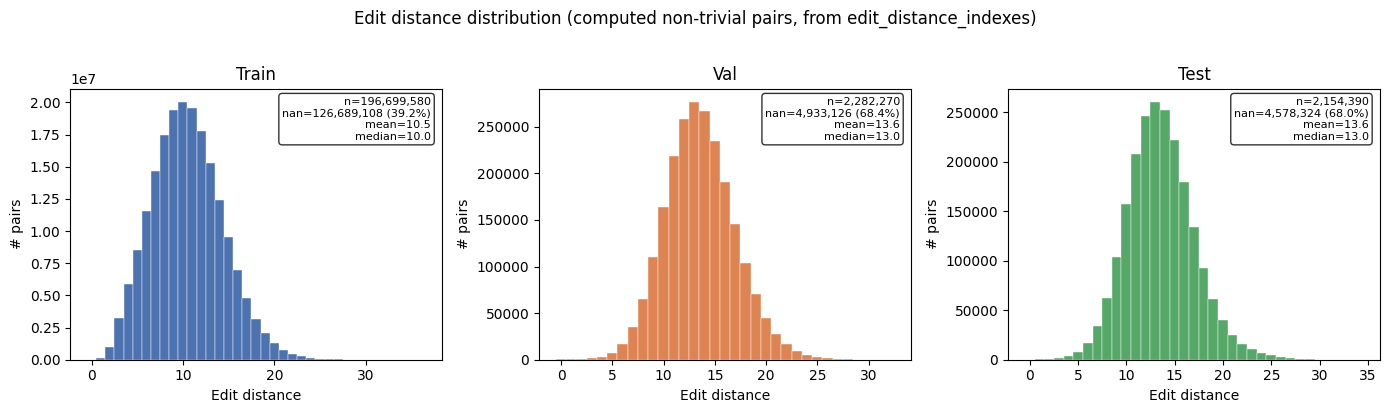

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, fold in zip(axes, FOLDS):
    dist = ed_arr[fold][:, 2]
    i_ed = ed_arr[fold][:, 0].astype(int)
    j_ed = ed_arr[fold][:, 1].astype(int)
    # Computed = not self-pair, not Tanimoto sentinel, not large-mol NaN
    comp_mask = ~((i_ed == j_ed) & (dist == 0)) & (dist != 666)
    ed    = dist[comp_mask & ~np.isnan(dist)]
    n_nan = np.isnan(dist[comp_mask]).sum()

    ax.hist(ed, bins=np.arange(-0.5, ed.max() + 1.5) if len(ed) else 20,
            color=FOLD_COLORS[fold], edgecolor="white", linewidth=0.3)
    ax.set_title(f"{fold.capitalize()}")
    ax.set_xlabel("Edit distance")
    ax.set_ylabel("# pairs")
    ax.text(0.97, 0.97,
            f"n={len(ed):,}\nnan={n_nan:,} ({n_nan/max(comp_mask.sum(),1)*100:.1f}%)\n"
            f"mean={ed.mean():.1f}\nmedian={np.median(ed):.1f}",
            transform=ax.transAxes, ha="right", va="top", fontsize=8,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.8))

plt.suptitle("Edit distance distribution (computed non-trivial pairs, from edit_distance_indexes)", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## 8. MCES vs Edit distance — joint (ed_mces_indexes)

`ed_mces_indexes` contains only pairs where **both** ED and MCES are non-NaN. All three folds shown.

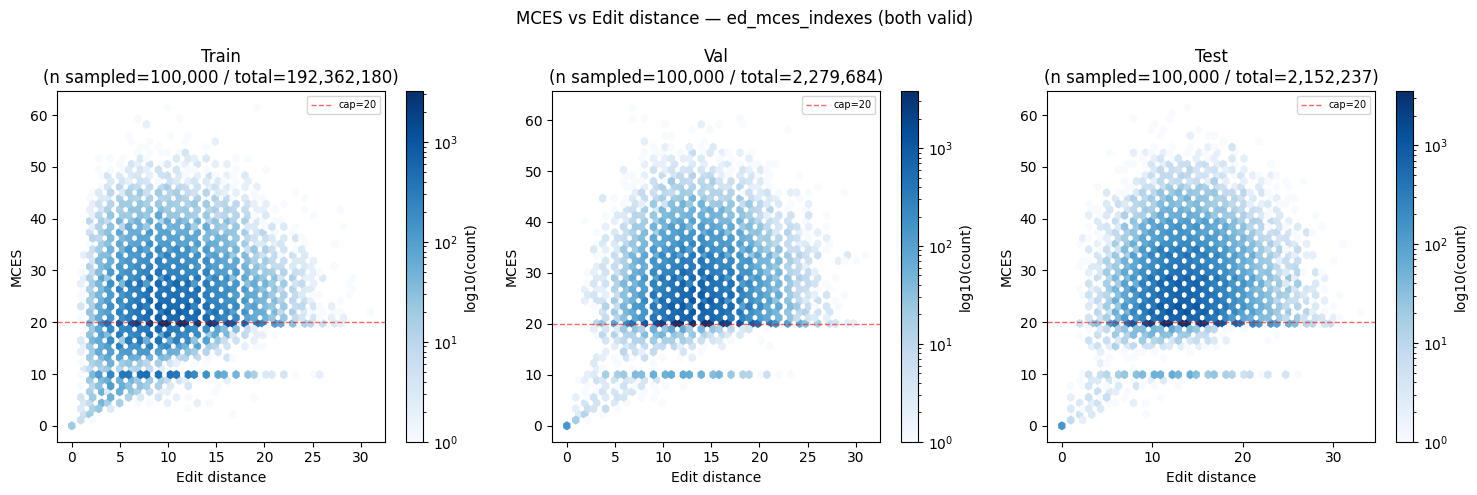

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fold in zip(axes, FOLDS):
    arr = edm_arr[fold]     # 4-col: [mol_i, mol_j, ED, MCES]
    ed_col   = arr[:, 2]
    mces_col = arr[:, 3]

    # Subsample for scatter (max 100k points)
    idx = np.arange(len(arr))
    if len(idx) > 100_000:
        rng = np.random.default_rng(42)
        idx = rng.choice(idx, 100_000, replace=False)

    ed_s, mces_s = ed_col[idx], mces_col[idx]

    h = ax.hexbin(ed_s, mces_s, gridsize=50, mincnt=1, cmap="Blues", bins="log")
    plt.colorbar(h, ax=ax, label="log10(count)")
    ax.set_xlabel("Edit distance")
    ax.set_ylabel("MCES")
    ax.set_title(f"{fold.capitalize()}\n(n sampled={len(idx):,} / total={len(arr):,})")
    ax.axhline(MCES_THRESHOLD, color="red", lw=1, ls="--", alpha=0.6, label=f"cap={MCES_THRESHOLD:.0f}")
    ax.legend(fontsize=7)

plt.suptitle("MCES vs Edit distance — ed_mces_indexes (both valid)", fontsize=12)
plt.tight_layout()
plt.show()

## 9. Discarded pairs breakdown — what gets dropped and why

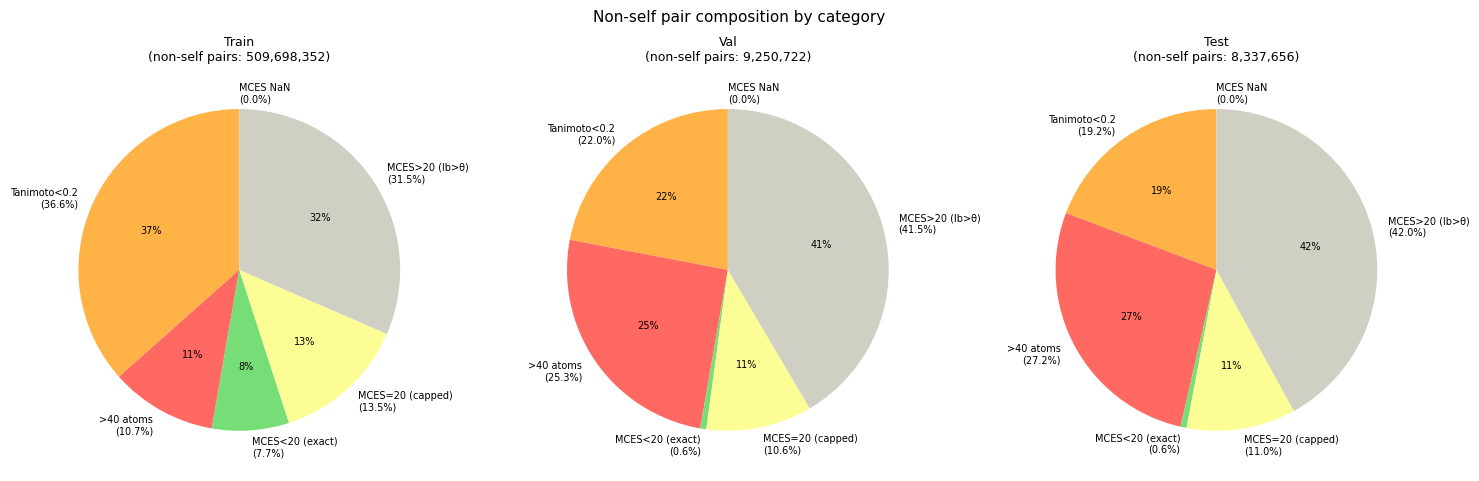

In [27]:
cat_labels_pie = ["Tanimoto<0.2", ">40 atoms",
                  "MCES<20 (exact)", "MCES=20 (capped)", "MCES>20 (lb>θ)", "MCES NaN"]
cat_keys_pie   = ["tani_low", "large_mol",
                  "mces_exact", "mces_capped", "mces_lb", "mces_nan"]
cat_colors_pie = ["#ffb347", "#ff6961",
                  "#77dd77", "#fdfd96", "#cfcfc4", "#d3b8e0"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, fold in zip(axes, FOLDS):
    c = cls[fold]
    # Exclude self-pairs from the pie
    non_self_total = (~c["self"]).sum()
    counts = [c[k].sum() for k in cat_keys_pie]

    wedges, texts, autotexts = ax.pie(
        counts,
        labels=[f"{l}\n({v/non_self_total*100:.1f}%)" for l, v in zip(cat_labels_pie, counts)],
        colors=cat_colors_pie,
        autopct=lambda p: f"{p:.0f}%" if p > 2 else "",
        startangle=90,
        textprops={"fontsize": 7},
    )
    ax.set_title(f"{fold.capitalize()}\n(non-self pairs: {non_self_total:,})", fontsize=9)

plt.suptitle("Non-self pair composition by category", fontsize=11)
plt.tight_layout()
plt.show()

## 10. Molecule atom count distribution (≤40 vs >40)

Test — molecules with >40 heavy atoms: 552 / 2888 (19.1%)


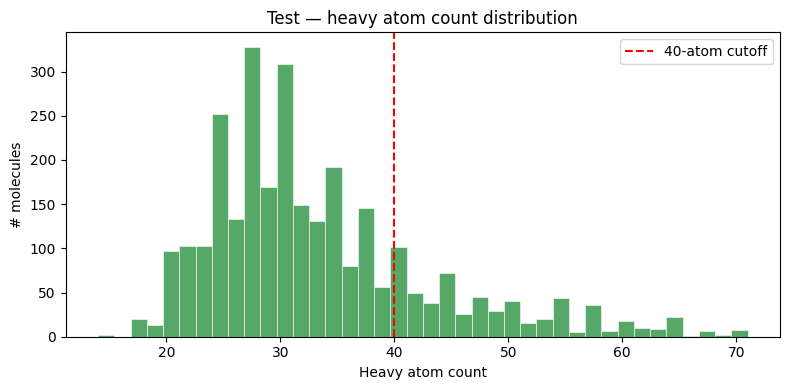

In [28]:
from rdkit import Chem

def count_heavy_atoms(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol.GetNumHeavyAtoms() if mol else np.nan
    except Exception:
        return np.nan

# Compute atom counts for test fold only (fast)
test_df = dfs["test"].copy()
test_df["n_atoms"] = test_df["canon_smiles"].apply(count_heavy_atoms)
print("Test — molecules with >40 heavy atoms:",
      (test_df["n_atoms"] > 40).sum(), "/", len(test_df),
      f"({(test_df['n_atoms'] > 40).mean()*100:.1f}%)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(test_df["n_atoms"].dropna(), bins=40, color=FOLD_COLORS["test"], edgecolor="white", linewidth=0.4)
ax.axvline(40, color="red", linestyle="--", linewidth=1.5, label="40-atom cutoff")
ax.set_xlabel("Heavy atom count")
ax.set_ylabel("# molecules")
ax.set_title("Test — heavy atom count distribution")
ax.legend()
plt.tight_layout()
plt.show()

## 11. Cumulative MCES distribution — how many pairs pass thresholds

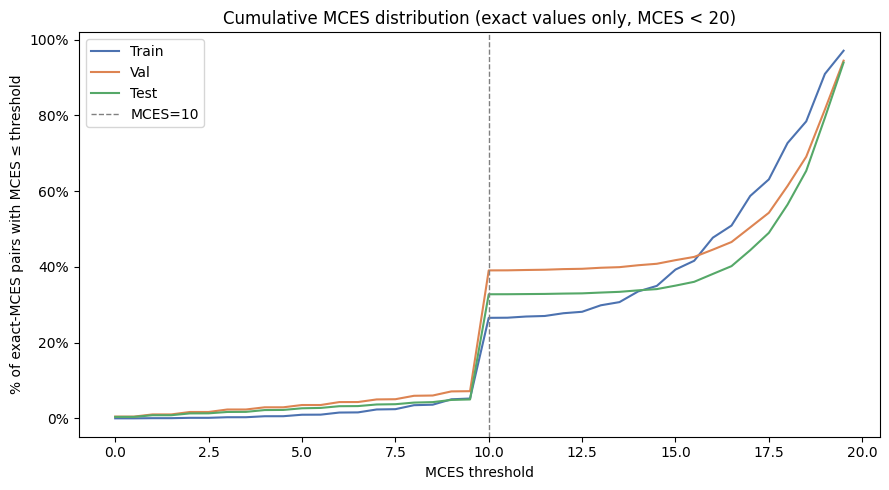

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))

thresholds = np.arange(0, MCES_THRESHOLD, 0.5)  # only exact values

for fold in FOLDS:
    # Use only exact values (MCES < threshold) — no capped/lb values
    exact = mces_arr[fold][cls[fold]["mces_exact"], 2]
    frac  = np.array([(exact <= t).mean() for t in thresholds])
    ax.plot(thresholds, frac * 100, label=fold.capitalize(), color=FOLD_COLORS[fold])

ax.axvline(10, color="gray", linestyle="--", linewidth=1, label="MCES=10")
ax.set_xlabel("MCES threshold")
ax.set_ylabel("% of exact-MCES pairs with MCES ≤ threshold")
ax.set_title(f"Cumulative MCES distribution (exact values only, MCES < {MCES_THRESHOLD:.0f})")
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
plt.tight_layout()
plt.show()

## 12. NaN fraction in computed pairs (timeout / failed MCES)

In [30]:
rows = []
for fold in FOLDS:
    c = cls[fold]
    comp = c["computed"].sum()

    ed_nan   = np.isnan(ed_arr[fold][:, 2])
    mces_nan = c["mces_nan"].sum()

    # Compute non-trivial ED rows (same filtering logic as classify)
    ed_dist  = ed_arr[fold][:, 2]
    i_ed     = ed_arr[fold][:, 0].astype(int)
    j_ed     = ed_arr[fold][:, 1].astype(int)
    ed_comp  = ~((i_ed == j_ed) & (ed_dist == 0)) & (ed_dist != 666)
    ed_nan_n = np.isnan(ed_dist[ed_comp]).sum()
    ed_comp_n = ed_comp.sum()

    rows.append({
        "Fold":                   fold,
        "Computed pairs (MCES)":  f"{comp:,}",
        "MCES NaN (timeout/fail)":f"{mces_nan:,}",
        "MCES NaN %":             f"{mces_nan/max(comp,1)*100:.3f}%",
        "Computed pairs (ED)":    f"{ed_comp_n:,}",
        "ED NaN (timeout/fail)":  f"{ed_nan_n:,}",
        "ED NaN %":               f"{ed_nan_n/max(ed_comp_n,1)*100:.3f}%",
        "Both ED+MCES valid":     f"{len(edm_arr[fold]):,}",
    })

pd.DataFrame(rows).set_index("Fold").T

Fold,train,val,test
Computed pairs (MCES),"268,782,561","4,879,563","4,467,544"
MCES NaN (timeout/fail),0,0,0
MCES NaN %,0.000%,0.000%,0.000%
Computed pairs (ED),"323,388,688","7,215,396","6,732,714"
ED NaN (timeout/fail),"126,689,108","4,933,126","4,578,324"
ED NaN %,39.175%,68.369%,68.001%
Both ED+MCES valid,"192,362,180","2,279,684","2,152,237"
